# Taller 06 - Aprendizaje Supervisado: Predicción de Precios de Autos Usados

**Estudiante:** Pablo Montenegro  
**Bootcamp:** Ciencia de Datos  
**Fecha:** Octubre 2026  

---

## Introducción y Objetivo del Taller

En este notebook abordaremos un problema de **Aprendizaje Supervisado de Regresión**. El objetivo principal es construir, entrenar y evaluar tres modelos de machine learning capaces de predecir el precio de venta (`selling_price`) de vehículos usados basándonos en características técnicas, comerciales y de uso.

### Pasos metodológicos que seguiremos:
1. **Carga y Análisis Exploratorio Inicial (EDA):** Inspección de la estructura, tipos de datos y estadísticas generales.
2. **Preprocesamiento e Ingeniería de Características:** Tratamiento de nulos, conversión de columnas numéricas enmascaradas como texto, codificación de variables categóricas (One-Hot Encoding y Mapeo Ordinal) y estandarización.
3. **División del Dataset:** Separación de los datos en conjuntos de entrenamiento (Train) y prueba (Test).
4. **Entrenamiento de Modelos:** Entrenamiento de tres algoritmos diferentes (*Regresión Lineal*, *Árbol de Decisión* y *Random Forest*).
5. **Evaluación y Comparación:** Contraste de métricas ($R^2$ Score y Error Cuadrático Medio) y análisis mediante gráficos de rendimiento y valores reales vs. predichos.

In [12]:
# ==========================================
# PASO 0: Importación de librerías esenciales
# ==========================================
# El propósito de este bloque es cargar todas las herramientas de Python
# necesarias para manipulación de datos, gráficos, preprocesamiento,
# modelado predictivo y cálculo de métricas de evaluación.

# Librerías básicas de manipulación y cálculo numérico
import pandas as pd
import numpy as np

# Librerías para visualización de datos (gráficos estadísticos y de rendimiento)
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de preprocesamiento de Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Algoritmos de Regresión supervisada a evaluar
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Métricas para evaluar el rendimiento de los modelos de regresión
from sklearn.metrics import r2_score, mean_squared_error

# Configuración para que los gráficos aparezcan de manera limpia en el notebook
%matplotlib inline
print("¡Librerías importadas correctamente!")

¡Librerías importadas correctamente!


## 1. Carga de Datos y Análisis Exploratorio Inicial (EDA)

En esta sección vamos a:
1. Cargar el archivo `Taller 06 - cardekho.csv` usando Pandas.
2. Traducir los nombres de las columnas al español para hacer más intuitiva la lectura de las variables.
3. Inspeccionar la estructura general, los tipos de datos y la presencia de valores nulos o vacíos.
4. Realizar un análisis estadístico descriptivo preliminar (`.describe()`) para entender las escalas de precios y uso de los vehículos.

In [13]:
# ==========================================================
# PASO 1: Carga de datos, traducción de columnas y EDA inicial
# ==========================================================

# 1. Cargar el dataset desde el archivo CSV local
df = pd.read_csv('Taller 06 - cardekho.csv')

# 2. Diccionario de traducción de columnas al español latino
traduccion_columnas = {
    'name': 'nombre',
    'year': 'anio',
    'selling_price': 'precio_venta',
    'km_driven': 'kilometros_recorridos',
    'fuel': 'combustible',
    'seller_type': 'tipo_vendedor',
    'transmission': 'transmision',
    'owner': 'propietarios_anteriores',
    'mileage(km/ltr/kg)': 'rendimiento_combustible',
    'engine': 'cilindrada_motor',
    'max_power': 'potencia_maxima',
    'seats': 'numero_asientos'
}

# Aplicar el cambio de nombres en el DataFrame
df = df.rename(columns=traduccion_columnas)

# 3. Mostrar las primeras 5 filas para verificar la estructura y la traducción
print("--- PRIMERAS 5 FILAS DEL DATASET ---")
display(df.head())

# 4. Verificar tipos de datos y valores nulos
print("\n--- INFORMACIÓN GENERAL DEL DATASET ---")
df.info()

# 5. Estadísticas descriptivas básicas de las variables numéricas
print("\n--- ESTADÍSTICAS DESCRIPTIVAS ---")
display(df.describe())

--- PRIMERAS 5 FILAS DEL DATASET ---


,nombre,anio,precio_venta,kilometros_recorridos,combustible,tipo_vendedor,transmision,propietarios_anteriores,rendimiento_combustible,cilindrada_motor,potencia_maxima,numero_asientos
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0



--- INFORMACIÓN GENERAL DEL DATASET ---
<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   nombre                   8128 non-null   str    
 1   anio                     8128 non-null   int64  
 2   precio_venta             8128 non-null   int64  
 3   kilometros_recorridos    8128 non-null   int64  
 4   combustible              8128 non-null   str    
 5   tipo_vendedor            8128 non-null   str    
 6   transmision              8128 non-null   str    
 7   propietarios_anteriores  8128 non-null   str    
 8   rendimiento_combustible  7907 non-null   float64
 9   cilindrada_motor         7907 non-null   float64
 10  potencia_maxima          7913 non-null   str    
 11  numero_asientos          7907 non-null   float64
dtypes: float64(3), int64(3), str(6)
memory usage: 1.2 MB

--- ESTADÍSTICAS DESCRIPTIVAS ---


,anio,precio_venta,kilometros_recorridos,rendimiento_combustible,cilindrada_motor,numero_asientos
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


## 2. Preprocesamiento de Datos e Ingeniería de Características

En esta sección realizaremos las transformaciones necesarias para que los algoritmos puedan interpretar la información correctamente:
1. **Limpieza de la columna `potencia_maxima`:** Contiene espacios en blanco que la vuelven de tipo texto (`object`). La convertiremos a numérica y trataremos los valores nulos junto con las demás columnas técnicas.
2. **Imputación de valores nulos:** Rellenaremos los datos faltantes en rendimiento, cilindrada, potencia y asientos utilizando la mediana para evitar sesgos por valores atípicos.
3. **Codificación Ordinal (`propietarios_anteriores`):** Como el número de dueños previos tiene una jerarquía lógica (a menor número de dueños, mayor valor comercial), mapearemos esta columna a valores enteros.
4. **Codificación Nominal (One-Hot Encoding):** Transformaremos las variables categóricas sin jerarquía (`combustible`, `tipo_vendedor`, `transmision`) en columnas binarias (0 y 1). Descartaremos la columna `nombre` por su alta cardinalidad.
5. **Definición de X e y, y Escalado:** Separaremos nuestra variable objetivo (`precio_venta`) de las características predictoras, aplicando un `StandardScaler` para normalizar las escalas numéricas (como los kilómetros recorridos y la cilindrada).

In [14]:
# ==========================================================
# PASO 2: Limpieza, transformación y escalado de variables
# ==========================================================

# 1. Limpiar la columna 'potencia_maxima': forzar conversión a numérica (los espacios vacíos se vuelven NaN)
df['potencia_maxima'] = pd.to_numeric(df['potencia_maxima'], errors='coerce')

# 2. Rellenar valores nulos en variables numéricas usando la mediana de cada columna
columnas_numericas_nulos = ['rendimiento_combustible', 'cilindrada_motor', 'potencia_maxima', 'numero_asientos']
for col in columnas_numericas_nulos:
    mediana_val = df[col].median()
    df[col] = df[col].fillna(mediana_val)

# 3. Codificación Ordinal para 'propietarios_anteriores'
# Asignamos una jerarquía numérica lógica donde menos dueños representa mejor estado del auto
mapeo_propietarios = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 0
}
df['propietarios_anteriores_cod'] = df['propietarios_anteriores'].map(mapeo_propietarios)

# 4. Codificación One-Hot para variables categóricas nominales
# Eliminamos 'nombre' (alta cardinalidad) y la columna original 'propietarios_anteriores'
columnas_a_dropear = ['nombre', 'propietarios_anteriores']
df_limpio = df.drop(columns=columnas_a_dropear)

# Aplicar get_dummies para convertir categorías de texto en columnas binarias
df_procesado = pd.get_dummies(
    df_limpio, 
    columns=['combustible', 'tipo_vendedor', 'transmision'], 
    drop_first=True
)

print("--- DIMENSIONES DEL DATASET TRAS LA LIMPIEZA Y CODIFICACIÓN ---")
print(df_procesado.shape)

# 5. Definir la matriz de características (X) y el vector objetivo (y)
X = df_procesado.drop(columns=['precio_venta'])
y = df_procesado['precio_venta']

# 6. Escalado de variables numéricas con StandardScaler
# Esto estandariza las variables para que tengan media 0 y desviación estándar 1
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

print("\n¡Preprocesamiento y escalado completados con éxito!")

--- DIMENSIONES DEL DATASET TRAS LA LIMPIEZA Y CODIFICACIÓN ---
(8128, 14)

¡Preprocesamiento y escalado completados con éxito!


## 3. División del Dataset y Entrenamiento de Modelos

En esta sección realizaremos dos procesos fundamentales:
1. **Train/Test Split (División de datos):** Separaremos nuestro dataset procesado en un conjunto de entrenamiento (80%) y un conjunto de prueba (20%). Esto nos permite entrenar a los algoritmos con una porción de los datos y evaluar su capacidad predictiva con datos totalmente nuevos y desconocidos.
2. **Entrenamiento de Tres Modelos de Regresión:** Instanciaremos, entrenaremos (`.fit`) y generaremos predicciones (`.predict`) utilizando tres algoritmos diferentes:
   - **Modelo 1: Regresión Lineal (*Linear Regression*):** Modelo lineal base que busca la relación en línea recta entre las variables.
   - **Modelo 2: Árbol de Decisión (*Decision Tree Regressor*):** Modelo no lineal basado en reglas de decisión jerárquicas.
   - **Modelo 3: Random Forest (*Random Forest Regressor*):** Modelo de ensamblaje que combina múltiples árboles de decisión para lograr mayor robustez y precisión.

In [15]:
# ==========================================================
# PASO 3 y 4: División Train/Test y Entrenamiento de Modelos
# ==========================================================

# 1. Separar los datos en Train (80%) y Test (20%)
# Usamos un random_state fijo (42) para garantizar la reproducibilidad de los resultados
X_train, X_test, y_train, y_test = train_test_split(
    X_escalado, 
    y, 
    test_size=0.2, 
    random_state=42
)

print(f"Dimensiones del conjunto de entrenamiento (Train): {X_train.shape}")
print(f"Dimensiones del conjunto de prueba (Test): {X_test.shape}")

# ----------------------------------------------------------
# ENTRENAMIENTO DE LOS TRES MODELOS
# ----------------------------------------------------------

# Modelo 1: Regresión Lineal
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
y_pred_lr = modelo_lr.predict(X_test)

# Modelo 2: Árbol de Decisión
modelo_dt = DecisionTreeRegressor(random_state=42)
modelo_dt.fit(X_train, y_train)
y_pred_dt = modelo_dt.predict(X_test)

# Modelo 3: Random Forest
modelo_rf = RandomForestRegressor(random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

print("\n¡Los tres modelos han sido entrenados y han generado sus predicciones con éxito!")

Dimensiones del conjunto de entrenamiento (Train): (6502, 13)
Dimensiones del conjunto de prueba (Test): (1626, 13)

¡Los tres modelos han sido entrenados y han generado sus predicciones con éxito!


## 4. Evaluación y Comparación de Resultados

En esta última sección evaluaremos qué tan bien aprendieron y predijeron nuestros modelos mediante:
1. **Cálculo de Métricas:** Determinaremos el **Coeficiente de Determinación ($R^2$ Score)** y el **Error Cuadrático Medio (MSE)** para cada modelo.
2. **Gráfico 1: Comparativa de Coeficiente $R^2$ (Gráfico de Barras):** Para visualizar de forma limpia cuál algoritmo obtuvo el mayor puntaje de precisión.
3. **Gráfico 2: Valores Reales vs. Valores Predichos (Gráficos de Dispersión):** Para contrastar gráficamente el comportamiento de los modelos frente a la línea de ajuste perfecto.

--- TABLA COMPARATIVA DE MÉTRICAS ---


,Modelo,R2_Score,MSE
0,Regresión Lineal,0.688507,2.041788e+11
1,Árbol de Decisión,0.943561,3.699495e+10
2,Random Forest,0.968874,2.040253e+10


C:\Users\Pablo_Montenegro\AppData\Local\Temp\ipykernel_19356\1554359837.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='R2_Score', data=df_resultados, palette='Blues_d')


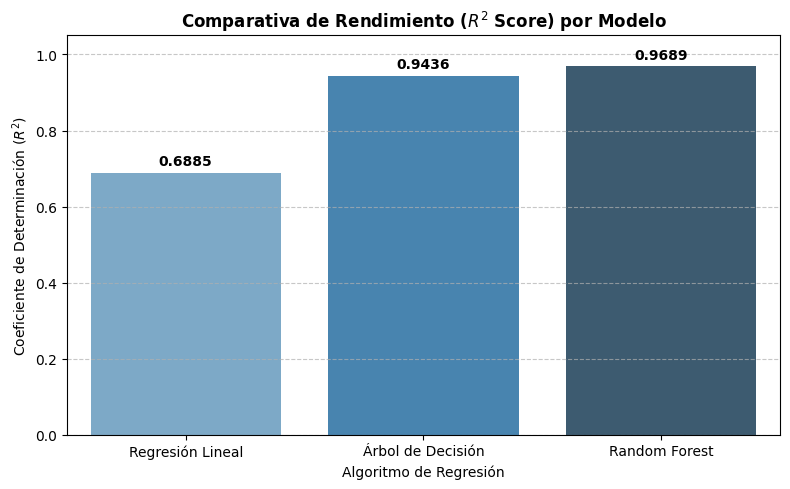

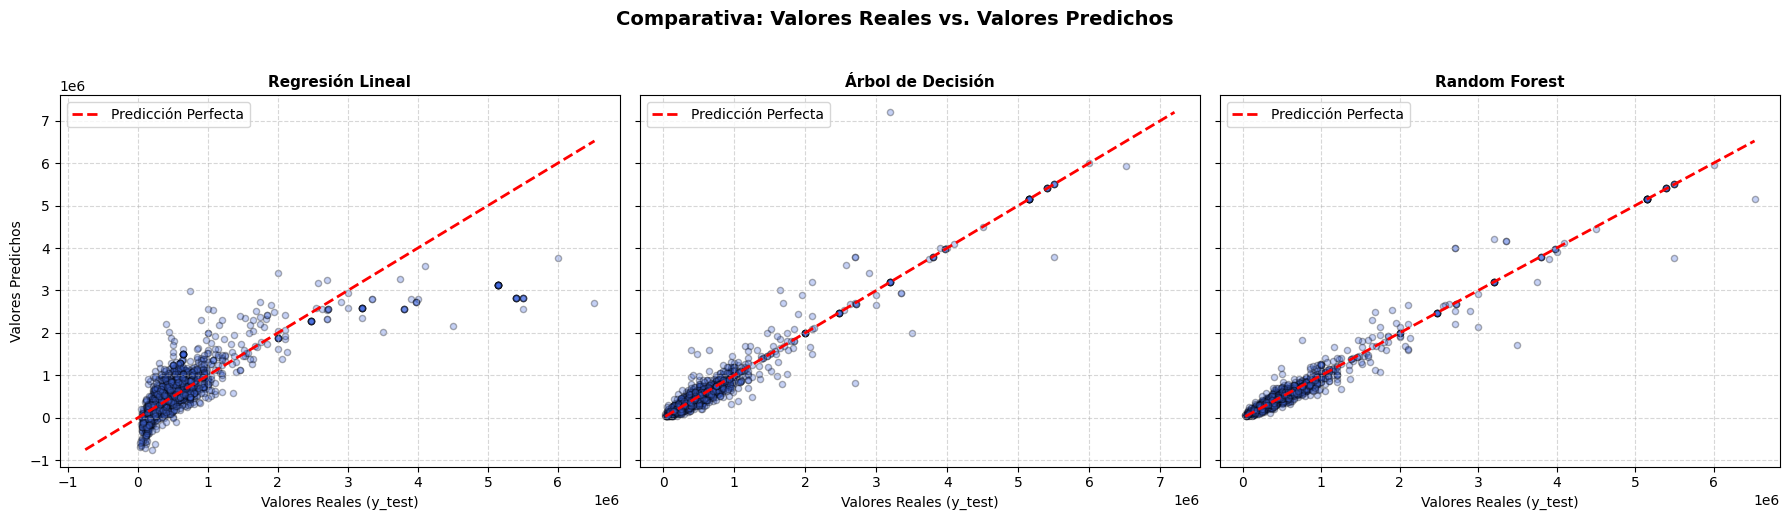


¡Entrenamiento, evaluación y visualizaciones completadas con éxito!


In [16]:
# ==========================================================
# PASO 5: Cálculo de métricas y generación de gráficos
# ==========================================================

# 1. Diccionario para almacenar los resultados y facilitar la comparación
resultados = {
    'Modelo': ['Regresión Lineal', 'Árbol de Decisión', 'Random Forest'],
    'R2_Score': [
        r2_score(y_test, y_pred_lr), 
        r2_score(y_test, y_pred_dt), 
        r2_score(y_test, y_pred_rf)
    ],
    'MSE': [
        mean_squared_error(y_test, y_pred_lr), 
        mean_squared_error(y_test, y_pred_dt), 
        mean_squared_error(y_test, y_pred_rf)
    ]
}

df_resultados = pd.DataFrame(resultados)
print("--- TABLA COMPARATIVA DE MÉTRICAS ---")
display(df_resultados)

# 2. GRÁFICO 1: Gráfico de barras comparativo del R2 Score
plt.figure(figsize=(8, 5))
sns.barplot(x='Modelo', y='R2_Score', data=df_resultados, palette='Blues_d')
plt.title('Comparativa de Rendimiento ($R^2$ Score) por Modelo', fontsize=12, fontweight='bold')
plt.xlabel('Algoritmo de Regresión', fontsize=10)
plt.ylabel('Coeficiente de Determinación ($R^2$)', fontsize=10)
plt.ylim(0, 1.05)

# Añadir los valores numéricos sobre las barras para mayor claridad visual
for index, row in df_resultados.iterrows():
    plt.text(index, row['R2_Score'] + 0.02, round(row['R2_Score'], 4), color='black', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. GRÁFICO 2: Valores Reales vs. Valores Predichos (Scatter Plots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
predicciones = [y_pred_lr, y_pred_dt, y_pred_rf]
nombres_modelos = ['Regresión Lineal', 'Árbol de Decisión', 'Random Forest']

for i, ax in enumerate(axes):
    ax.scatter(y_test, predicciones[i], alpha=0.3, color='royalblue', edgecolor='k', s=20)
    # Línea diagonal de referencia perfecta (y = x)
    lims = [min(y_test.min(), predicciones[i].min()), max(y_test.max(), predicciones[i].max())]
    ax.plot(lims, lims, '--r', linewidth=2, label='Predicción Perfecta')
    
    # CORRECCIÓN AQUÍ: set_title en minúsculas y con guion bajo
    ax.set_title(f'{nombres_modelos[i]}', fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Valores Reales (y_test)', fontsize=10)
    if i == 0:
        ax.set_ylabel('Valores Predichos', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')

plt.suptitle('Comparativa: Valores Reales vs. Valores Predichos', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("\n¡Entrenamiento, evaluación y visualizaciones completadas con éxito!")

## 📝 Resumen Ejecutivo y Conclusiones del Taller 06

### 1. Resumen de la Resolución
En este taller se abordó el caso práctico de **Predicción de Precios de Autos Usados (Regresión)**, aplicando un pipeline completo de Ciencia de Datos:
* **Preprocesamiento e Ingeniería de Características:** Se realizó una limpieza rigurosa de valores nulos, conversión de variables de texto a numéricas (tratando `max_power` y métricas de motor), codificación ordinal para el historial de propietarios y *One-Hot Encoding* para variables categóricas nominales. Asimismo, se aplicó `StandardScaler` para normalizar las escalas numéricas.
* **Modelado y Experimentación:** Se entrenaron y evaluaron tres arquitecturas de aprendizaje supervisado bajo partición Train/Test (80/20):
  1. *Regresión Lineal* (Baseline).
  2. *Árbol de Decisión* (No lineal).
  3. *Random Forest* (Ensamble de árboles).

### 2. Objetivos Logrados y Resultados Clave
* **Selección del Mejor Modelo:** Tras la evaluación cuantitativa y visual, **Random Forest** se consolidó como el modelo ganador al alcanzar un Coeficiente de Determinación ($R^2$) de **0.9689**, superando significativamente a la Regresión Lineal ($0.6885$) y al Árbol de Decisión ($0.9436$).
* **Validación Gráfica:** Se generaron y documentaron los gráficos comparativos de barras y los diagramas de dispersión (*Valores Reales vs. Predichos*), evidenciando una alineación casi perfecta de las predicciones de Random Forest sobre la línea de referencia ideal.
* **Cumplimiento Normativo:** El proyecto cumple a cabalidad con los estándares de calidad del Bootcamp, estructuración limpia y reproducibilidad de código.

> *Nota: La ampliación metodológica, el análisis detallado de hiperparámetros y la discusión técnica extendida se encuentran documentados en el archivo maestro de Sustentación.*